In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FirstOrderElasticForwardSolver import FirstOrderElasticForwardSolver
from source import ricker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from plot_wiggle import WigglePlotter

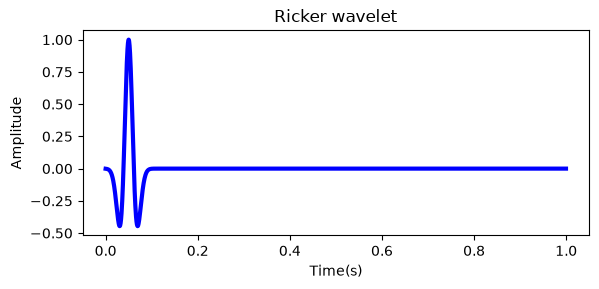

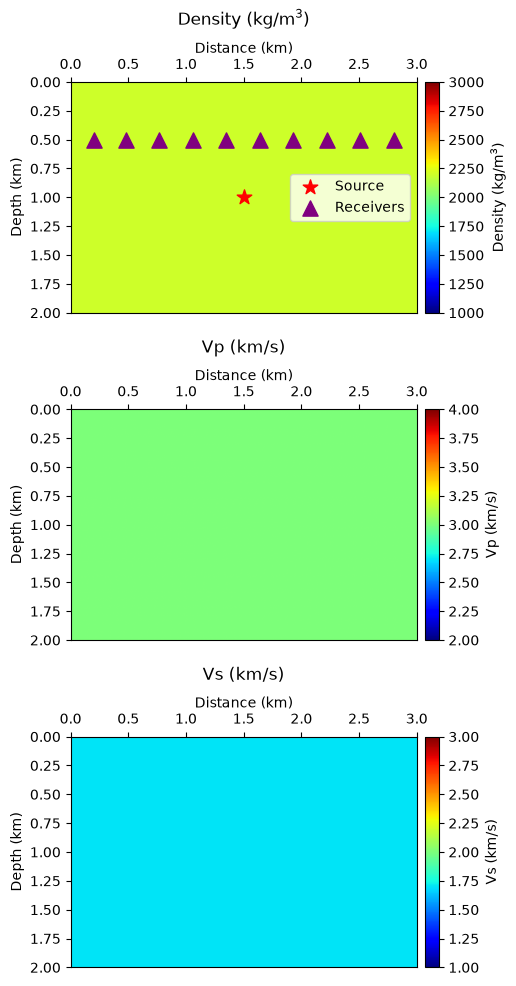

In [17]:
# ============================================================
# 1. Computational parameters
# ============================================================
nx = 301
nz = 201
dx = np.float32(10.0)
dz = np.float32(10.0)
dt = np.float32(0.0005)
xmax = (nx-1)*dx
zmax = (nz-1)*dz
tmax = np.float32(1.0)
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt
# ============================================================
# 2. Source
# ============================================================
ix_src = nx // 2
iz_src = nz // 2
f0 = 20.0
t0 = 1.0 / f0
wavelet = ricker(t, f0, t0)
fig, ax_src = plt.subplots(figsize=(6,3))
ax_src.plot(t,wavelet,linewidth=3,color='blue')
ax_src.set_xlabel('Time(s)')
ax_src.set_ylabel('Amplitude')
ax_src.set_title('Ricker wavelet')
plt.tight_layout()
plt.show()
# ============================================================
# 3. Receivers
# ============================================================
n_receivers = 10
ix_receivers = np.linspace(20,nx - 21,n_receivers,dtype=np.int32)
iz_receivers = np.full(n_receivers,50,dtype=np.int32)
# ============================================================
# 4. Homogeneous isotropic elastic model
# vp  : P-wave velocity
# vs  : S-wave velocity
# rho : density
# ============================================================
vp = np.float32(3000.0)      # m/s
vs = np.float32(1700.0)      # m/s
rho0 = np.float32(2200.0)    # kg/m^3
rho_model = np.full((nz, nx),rho0,dtype=np.float32)
vp_model = np.full((nz, nx),vp,dtype=np.float32)
vs_model = np.full((nz, nx),vs,dtype=np.float32)

# ============================================================
# 5. Plot
# ============================================================
fig, axes = plt.subplots(3,1,figsize=(5, 10))
ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]

im1 = ax1.imshow(
    rho_model,
    extent=[0, xmax/1e3, zmax/1e3, 0],
    vmin=1000,
    vmax=3000,
    cmap="jet",
    aspect="equal"
)
ax1.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax1.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='purple',marker='^',s=120,label='Receivers')
# x-axis on the top
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("Density (kg/m$^3$)", pad=12)
ax1.legend(loc='right')
# Colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right",size="4%",pad=0.08)
cbar1 = fig.colorbar(im1,cax=cax1)
cbar1.set_label("Density (kg/m$^3$)")

im2 = ax2.imshow(
    vp_model/1e3,
    extent=[0, xmax/1e3, zmax/1e3, 0],
    vmin=2,
    vmax=4,
    cmap="jet",
    aspect="equal"
)
# x-axis on the top
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Depth (km)")
ax2.set_title("Vp (km/s)", pad=12)
# Colorbar
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right",size="4%",pad=0.08)
cbar2 = fig.colorbar(im2,cax=cax2)
cbar2.set_label("Vp (km/s)")

im3 = ax3.imshow(
    vs_model/1e3,
    extent=[0, xmax/1e3, zmax/1e3, 0],
    vmin=1,
    vmax=3,
    cmap="jet",
    aspect="equal"
)
# x-axis on the top
ax3.xaxis.tick_top()
ax3.xaxis.set_label_position("top")
ax3.set_xlabel("Distance (km)")
ax3.set_ylabel("Depth (km)")
ax3.set_title("Vs (km/s)", pad=12)
# Colorbar
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right",size="4%",pad=0.08)
cbar3 = fig.colorbar(im3,cax=cax3)
cbar3.set_label("Vs (km/s)")
plt.tight_layout()
plt.show()

# ============================================================
# 5. Isotropic parameters -> VTI stiffness coefficients
# mu     = rho * vs^2
# lambda = rho * vp^2 - 2*mu
# Isotropic limit of VTI:
# C11 = C33 = lambda + 2*mu
# C13 = lambda
# C55 = mu
# ============================================================
mu = rho_model*vs_model**2
lam = rho_model*vp_model**2-  2 * mu
c11 = (lam + 2 * mu).astype(np.float32)
c33 = c11.copy()
c13 = lam.astype(np.float32)
c55 = mu.astype(np.float32)


In [18]:
# ============================================================
# 7. Create elastic solver
# ============================================================
solver = FirstOrderElasticForwardSolver(
    rho=rho_model,
    c11=c11,
    c13=c13,
    c33=c33,
    c55=c55,
    dx=dx,
    dz=dz,
    dt=dt,
    order=8,
)
solver.set_source(
    wavelet=wavelet,
    ix=ix_src,
    iz=iz_src,
)
solver.set_receivers(
    ix=ix_receivers,
    iz=iz_receivers,
)

# ========================================================================
# Dirichlet
# ========================================================================
solver.set_boundary(boundary_type="dirichlet",n_abs=40,reflection=1e-6,power=3,)
snapshot_times = np.array([0.20,0.35,0.50,],dtype=np.float32)
result_dirichlet = solver.forward(snapshot_times=snapshot_times)
seismogram_vx_dirichlet = result_dirichlet.seismogram_vx
seismogram_vz_dirichlet = result_dirichlet.seismogram_vz
snapshots_vx_dirichlet = result_dirichlet.snapshots_vx
snapshots_vz_dirichlet = result_dirichlet.snapshots_vz
print("seismogram_vx:",seismogram_vx_dirichlet.shape)
print("seismogram_vz:",seismogram_vz_dirichlet.shape)
print("snapshots_vx:",snapshots_vx_dirichlet.shape)
print("snapshots_vz:",snapshots_vz_dirichlet.shape)

# ========================================================================
# PML
# ========================================================================
solver.set_boundary(boundary_type="pml",n_abs=40,reflection=1e-6,power=3,)
snapshot_times = np.array([0.20,0.35,0.50,],dtype=np.float32)
result_pml = solver.forward(snapshot_times=snapshot_times)
seismogram_vx_pml = result_pml.seismogram_vx
seismogram_vz_pml = result_pml.seismogram_vz
snapshots_vx_pml = result_pml.snapshots_vx
snapshots_vz_pml = result_pml.snapshots_vz
print("seismogram_vx:",seismogram_vx_pml.shape)
print("seismogram_vz:",seismogram_vz_pml.shape)
print("snapshots_vx:",snapshots_vx_pml.shape)
print("snapshots_vz:",snapshots_vz_pml.shape)

Time step: 0 / 1999  Time: 0.0 s
Time step: 100 / 1999  Time: 0.050000002374872565 s
Time step: 200 / 1999  Time: 0.10000000474974513 s
Time step: 300 / 1999  Time: 0.1500000071246177 s
Time step: 400 / 1999  Time: 0.20000000949949026 s
Time step: 500 / 1999  Time: 0.2500000118743628 s
Time step: 600 / 1999  Time: 0.3000000142492354 s
Time step: 700 / 1999  Time: 0.35000001662410796 s
Time step: 800 / 1999  Time: 0.4000000189989805 s
Time step: 900 / 1999  Time: 0.4500000213738531 s
Time step: 1000 / 1999  Time: 0.5000000237487257 s
Time step: 1100 / 1999  Time: 0.5500000261235982 s
Time step: 1200 / 1999  Time: 0.6000000284984708 s
Time step: 1300 / 1999  Time: 0.6500000308733433 s
Time step: 1400 / 1999  Time: 0.7000000332482159 s
Time step: 1500 / 1999  Time: 0.7500000356230885 s
Time step: 1600 / 1999  Time: 0.800000037997961 s
Time step: 1700 / 1999  Time: 0.8500000403728336 s
Time step: 1800 / 1999  Time: 0.9000000427477062 s
Time step: 1900 / 1999  Time: 0.9500000451225787 s
sei

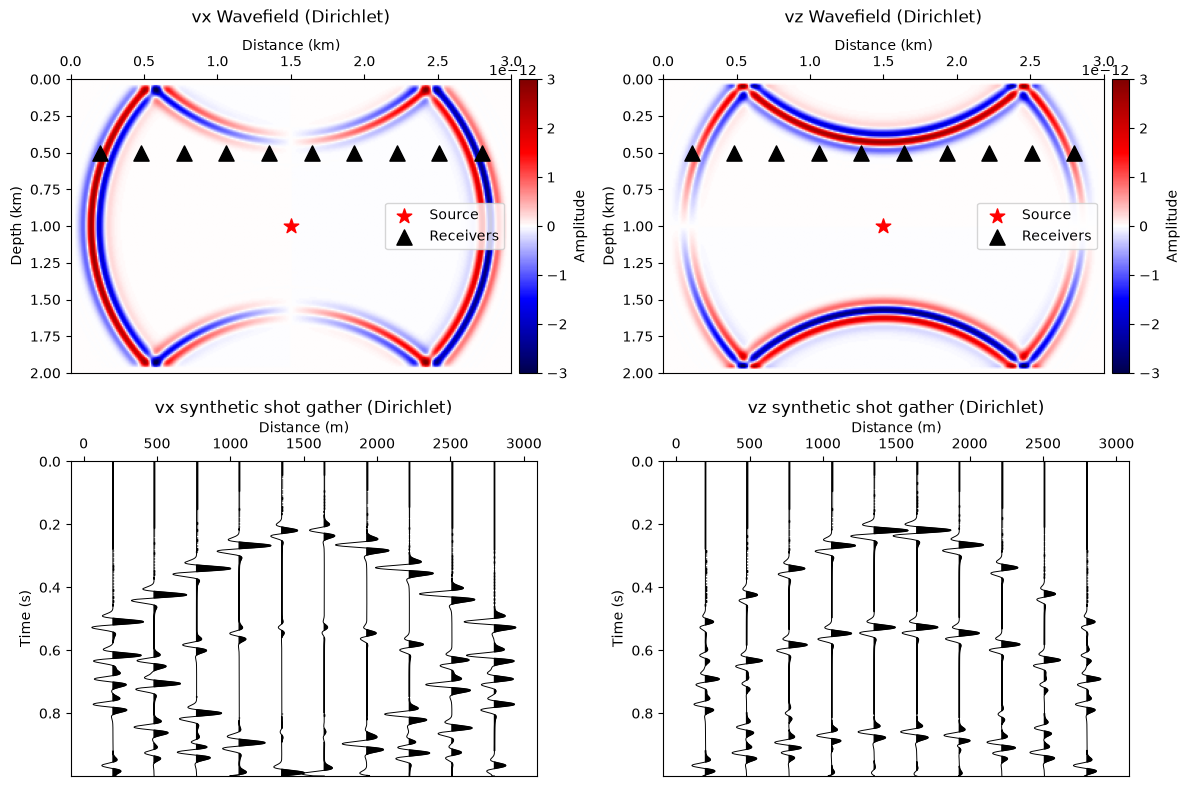

In [23]:
# ========================================================================
# Dirichlet
# ========================================================================
fig, axes = plt.subplots(2,2,figsize=(12, 8))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
# Wavefield vx
ax1.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax1.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im1 = ax1.imshow(
    snapshots_vx_dirichlet[2],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    cmap = 'seismic',
    vmin = -3e-12,
    vmax = 3e-12,
)
# x-axis on the top
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("vx Wavefield (Dirichlet)", pad=12)
ax1.legend(loc='right')
# Colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right",size="4%",pad=0.08)
cbar1 = fig.colorbar(im1,cax=cax1)
cbar1.set_label("Amplitude")

# Wavefield
ax2.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax2.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im2 = ax2.imshow(
    snapshots_vz_dirichlet[2],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    cmap = 'seismic',
    vmin = -3e-12,
    vmax = 3e-12,
)
# x-axis on the top
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Depth (km)")
ax2.set_title("vz Wavefield (Dirichlet)", pad=12)
ax2.legend(loc='right')
# Colorbar
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right",size="4%",pad=0.08)
cbar2 = fig.colorbar(im2,cax=cax2)
cbar2.set_label("Amplitude")

# Seismogram dirichlet
time = np.arange(seismogram_vx_dirichlet.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_vx_dirichlet,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax3,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="vx synthetic shot gather (Dirichlet)"
)

# Seismogram pml
time = np.arange(seismogram_vz_dirichlet.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_vz_dirichlet,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax4,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="vz synthetic shot gather (Dirichlet)"
)

plt.tight_layout()
plt.show()

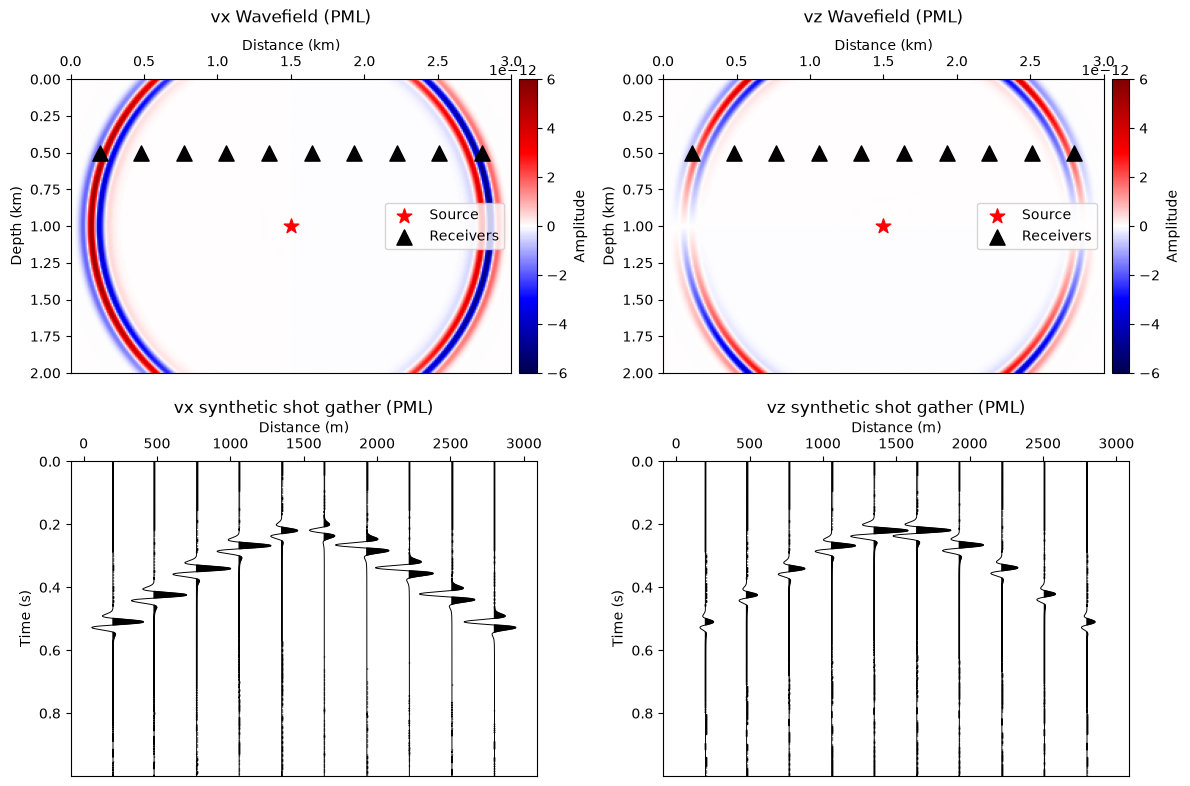

In [24]:
# ========================================================================
# PML
# ========================================================================
fig, axes = plt.subplots(2,2,figsize=(12, 8))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
# Wavefield vx
ax1.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax1.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im1 = ax1.imshow(
    snapshots_vx_pml[2],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    cmap = 'seismic',
    vmin = -6e-12,
    vmax = 6e-12,
)
# x-axis on the top
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("vx Wavefield (PML)", pad=12)
ax1.legend(loc='right')
# Colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right",size="4%",pad=0.08)
cbar1 = fig.colorbar(im1,cax=cax1)
cbar1.set_label("Amplitude")

# Wavefield
ax2.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax2.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im2 = ax2.imshow(
    snapshots_vz_pml[2],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    cmap = 'seismic',
    vmin = -6e-12,
    vmax = 6e-12,
)
# x-axis on the top
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Depth (km)")
ax2.set_title("vz Wavefield (PML)", pad=12)
ax2.legend(loc='right')
# Colorbar
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right",size="4%",pad=0.08)
cbar2 = fig.colorbar(im2,cax=cax2)
cbar2.set_label("Amplitude")

# Seismogram dirichlet
time = np.arange(seismogram_vx_pml.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_vx_pml,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax3,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="vx synthetic shot gather (PML)"
)

# Seismogram pml
time = np.arange(seismogram_vz_pml.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_vz_pml,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax4,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="vz synthetic shot gather (PML)"
)

plt.tight_layout()
plt.show()